## Actividad usando Label Studio
Para ello vamos a aprender como se instala Label Studio en nuestro entorno virtual de Python, para ello deberemos de ejecutar lo siguiente.

In [3]:
## En el caso de que no utilice Anaconda como kernel, deberemos de crear un venv de python para poder instalar paquetes de python.

%python -m .venv venv
%source venv/bin/activate

%pip install label-studio

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [28]:
!label-studio

/bin/bash: línea 1: label-studio: orden no encontrada


Después de haber ejecutado los siguientes comandos, se nos abrira de forma automática en el navegador, una ventana en localhost:8080. De primeras nos pedira iniciar sesión con una cuenta, en caso de que no tengamos deberemos de registrarnos. Una vez dentro, accederemos a un menú en el cual podremos crear un proyecto para más tarde asi empezar a poder etiquetar las imagenes.

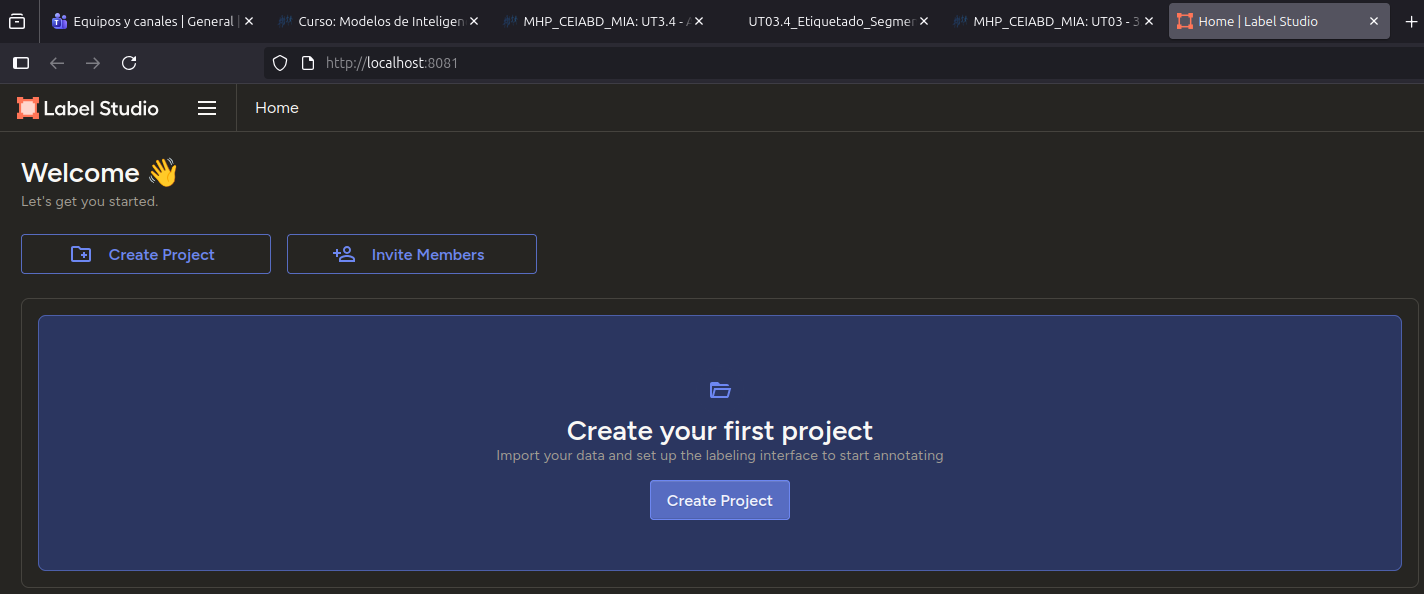

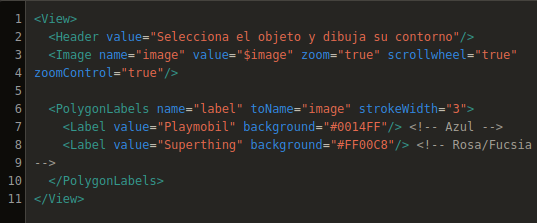

Después de haber creado nuestro proyecto y subir las imagenes, deberemos de crear un modelo de marcado

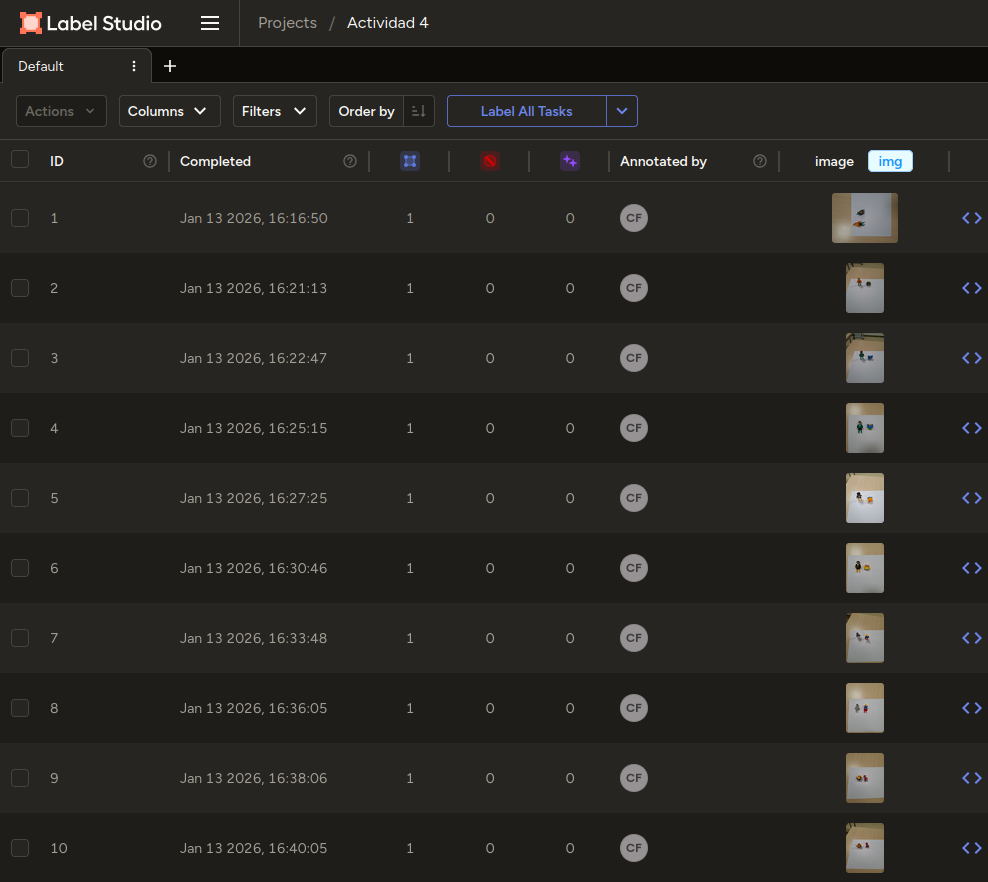

Después de haber etiquetado cada imagen, deberemos de exportar los resultados ya que sin ellos no podremos seguir para entrenar el modelo. Como mas tarde vamos a estar trabajando con YOLO para entrenar el modelo, deberemos de expotar mediante la siguiente opción. Esto genera un zip el cual contiene lo siguiente:

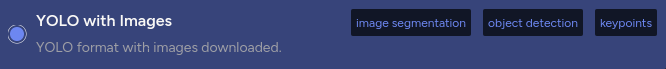

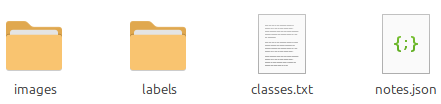

Para entrenar el modelo deberemos de hacer la estructura de carpetas necesaria para que funcione YOLO correctamente.

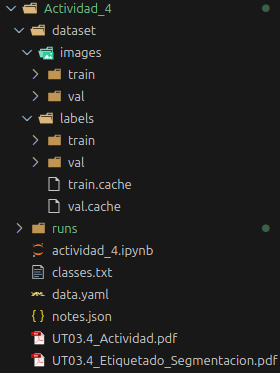

Una vez hecho esto, deberemos de hacer el codigo necesario para poder entrenar el modelo. Aunque previamente deberemos de replicar la estructura de carpetas que sigue YOLO para su entrenamiento

In [31]:
from ultralytics import YOLO

model = YOLO("yolo11s-seg.pt")

results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0
)


New https://pypi.org/project/ultralytics/8.4.6 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train6, nbs=64, nms=False, opset=None, opt

## Validacion de resultados

In [32]:
from ultralytics import YOLO

model = YOLO("runs/segment/train6/weights/best.pt")
metrics = model.val(data="data.yaml", imgsz=640, device=0)


Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
YOLO11s-seg summary (fused): 113 layers, 10,067,590 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8257.2±719.3 MB/s, size: 2095.6 KB)
val: Scanning /home/ciabd10/Descargas/MIA/Actividad_4/dataset/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 15.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
                   all          4          8      0.925      0.899      0.897      0.864      0.925      0.899      0.897       0.74
           Superthings          2          3       0.85          1      0.995      0.929       0.85          1      0.995       0.84
             Playmobil          3          5          1      0.798      0.798      0.798          1      0.798      0.798      0.639
Speed

## Breve Reflexión
### ¿Describe cuales son los elementos que presentan mayor complejidad de etiquetado?






Los elementos mas dificiles de etiquetar son aquellos elementos que son muy pequeños y dificiles de etiquetar con precision. Esto hace que al final el modelo entrene con peores datos y el resultado sea peor.

No solo es si el objeto es pequeño o se realizo la foto de lejos, sino que tambien se debe a que la fotografía se hiciese enfocando bien el objeto o no.

Al juntar el dataset con el de todos, el resultado no fue el más optimo, debido a que el XML es probable que haya variado. Sin embargo, al realizarlo con el propio dataset, la precision del modelo aumenta considerablemente